In [23]:
from lorenzo_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)



c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Maru\lorenzo_utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [3]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [6]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = cmap(0), label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')

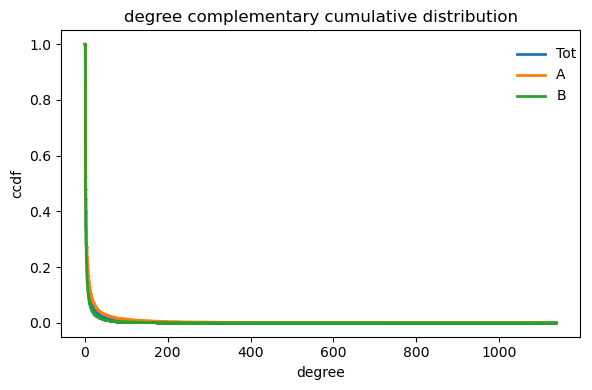

In [24]:
plot_ccdf(G, 'degree', log=False)

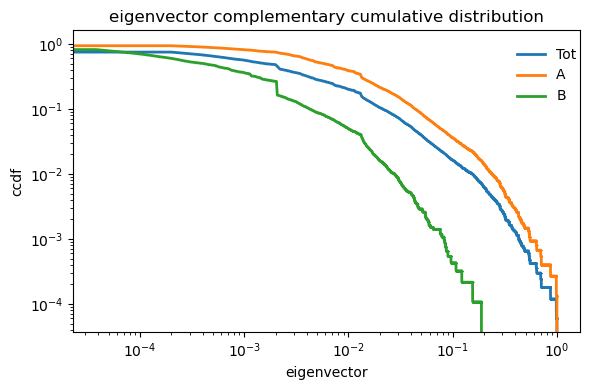

In [6]:
plot_ccdf(G, 'eigenvector', log=True)

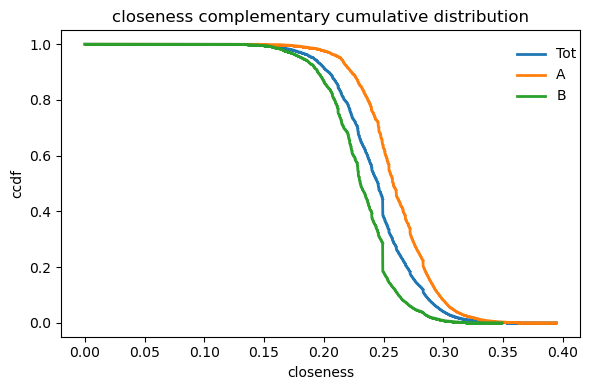

In [7]:
plot_ccdf(G, 'closeness', log=False)

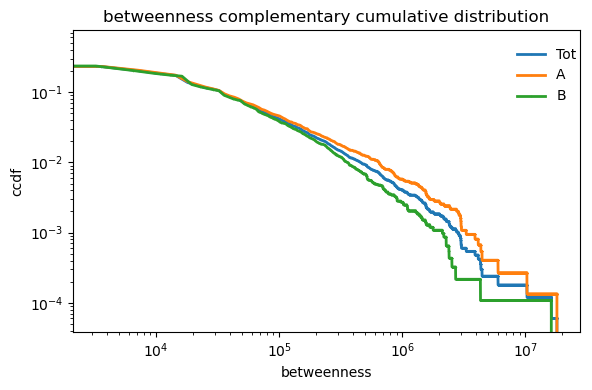

In [8]:
plot_ccdf(G, 'betweenness', log=True)

# Scatter plot

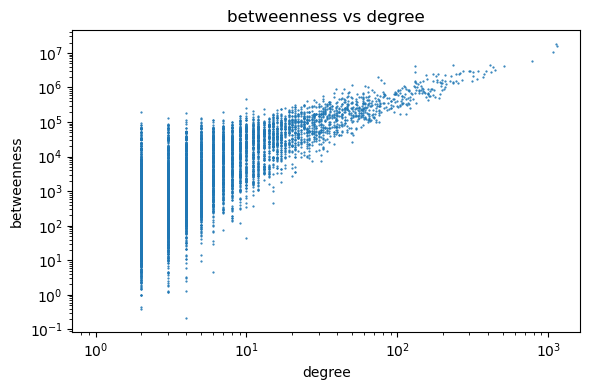

In [9]:
fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
ax.scatter(G.vs['degree'], G.vs['betweenness'], s=0.3, color=cmap(0))
ax.set_title('betweenness vs degree')
ax.set_xlabel('degree')
ax.set_ylabel('betweenness')
ax.set_xscale('log')
ax.set_yscale('log')

# Distribuzioni di misure di centralità

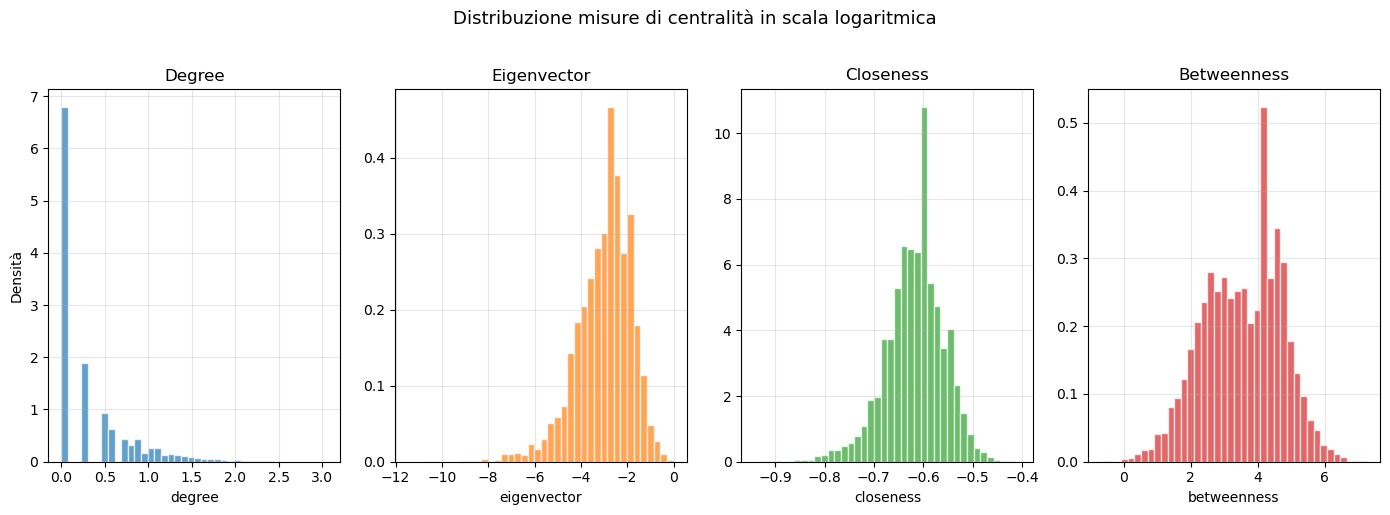

In [10]:
metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
colors = [cmap(i) for i in range(len(metrics))]

for ax, m, color in zip(axes, metrics, colors):
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]
    
    ax.hist(np.log10(values), bins=40, density=True,
            color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità" if ax == axes[0] else "")
    ax.grid(alpha=0.3)

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()

Domanda:
sono gli stessi nodi a generare i picchi nei vari grafici?

In [ ]:
metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = [cmap(i) for i in range(len(metrics))]

values = np.array(G.vs[metric])
k_values, ccdf = compute_ccdf(values)
kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

for ax, m, color in zip(axes, metrics, colors):
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]

    valuesA = values[[group == 'A' for group in G.vs['group']]]
    valuesB = values[[group == 'B' for group in G.vs['group']]]
    
    ax.hist(np.log10(values), bins=40, density=True,
            color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità" if ax == axes[0] else "")
    ax.grid(alpha=0.3)

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()

# Spearman rank

In [13]:
from scipy.stats import spearmanr

metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
df = pd.DataFrame({m: G.vs[m] for m in metrics})

# --- Matrice di correlazione di Spearman ---
corr_matrix, p_matrix = spearmanr(df)
corr_df = pd.DataFrame(corr_matrix, index=metrics, columns=metrics)

print(corr_df.round(3))

             degree  eigenvector  closeness  betweenness
degree        1.000        0.549      0.596        0.943
eigenvector   0.549        1.000      0.979        0.470
closeness     0.596        0.979      1.000        0.522
betweenness   0.943        0.470      0.522        1.000


[Text(0, 0, 'degree'),
 Text(0, 1, 'closeness'),
 Text(0, 2, 'betweenness'),
 Text(0, 3, 'coreness')]

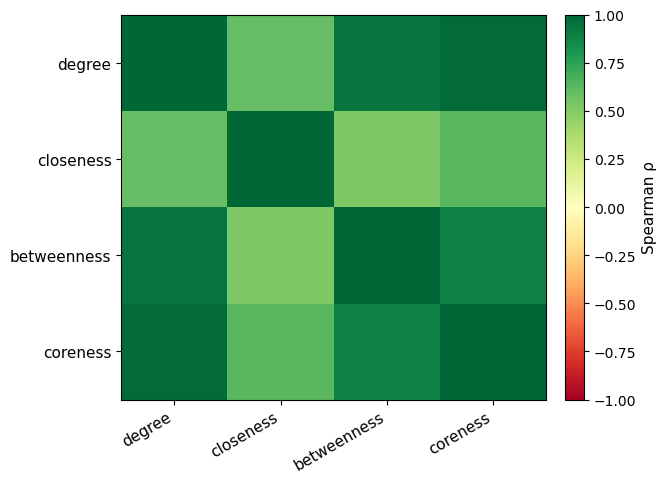

In [22]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors

# --- 2. Calcola le centralità ---
centralities = {
    'degree':      G.vs['degree'],
    'closeness':   G.vs['closeness'],
    'betweenness': G.vs['betweenness'],
    'coreness':    G.vs['coreness'],
}

labels = list(centralities.keys())
n = len(labels)
data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

# --- 3. Matrice di correlazione di Spearman ---
corr_matrix = np.ones((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        r, p = spearmanr(data[i], data[j])
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

# --- 4. Plot heatmap con matplotlib puro ---
fig, ax = plt.subplots(figsize=(6, 5))

# Colormap divergente centrata su 0
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(corr_matrix, cmap=cmap, norm=norm, aspect='auto')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)

# Etichette assi
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

